In [55]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
import sklearn 
from random import sample
from scipy.stats import norm 
from astroML.datasets import fetch_dr7_quasar  

<function matplotlib.pyplot.show(close=None, block=None)>

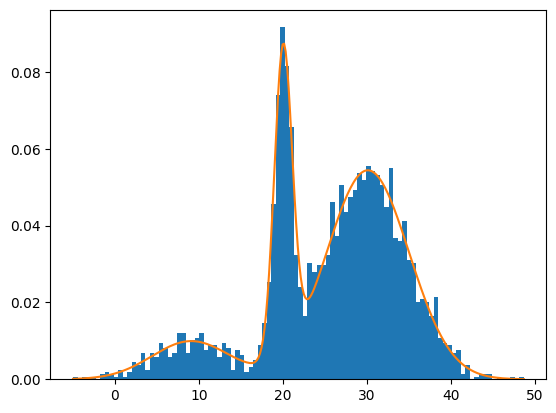

In [87]:
data=np.load("formationchannels.npy")
plt.hist(data, 100, density=True) # maybe three models

x=np.linspace(np.min(data), np.max(data),300)

gm = sklearn.mixture.GaussianMixture(n_components=3).fit(data)
y=x[:,np.newaxis] #data in the right format 

w=gm.score_samples(y)
plt.plot(x,np.exp(w))
plt.show 

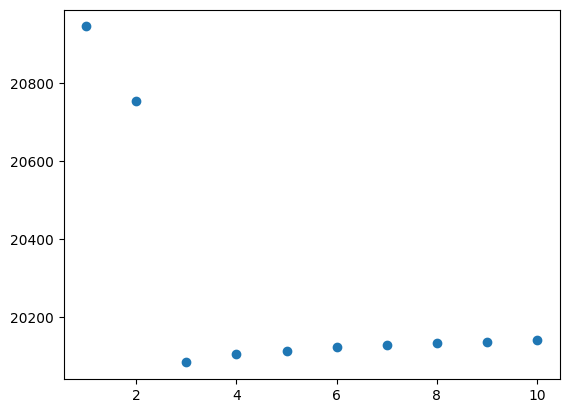

In [84]:
aics=[]
xa=(np.linspace(1,10,10, dtype=int))
for i in xa:
    fg=sklearn.mixture.GaussianMixture(n_components=i).fit(data)
    aics.append(fg.aic(data))
plt.scatter(xa, aics)

### Gaussian mode ###


[]

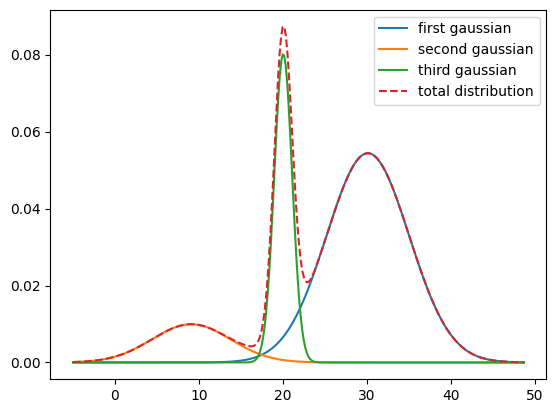

In [127]:
a=gm.predict_proba(y)

plt.plot(y,a[:,0]*np.exp(w), label="first gaussian") #each weight multiply for the total gaussian 
plt.plot(y,a[:,1]*np.exp(w), label="second gaussian")
plt.plot(y,a[:,2]*np.exp(w), label="third gaussian")
plt.plot(x,np.exp(w), linestyle='--', label="total distribution")
plt.legend()
plt.plot()
